In [2]:
df = pd.read_parquet(RAW / "codenet_cpp_metadata.parquet")
print(f"Rows:    {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"Memory:  {df.memory_usage(deep=True).sum()/1e9:.2f} GB")
df.head(3)

Rows:    8,008,527
Columns: ['submission_id', 'problem_id', 'user_id', 'date', 'language', 'original_language', 'filename_ext', 'status', 'cpu_time', 'memory', 'code_size']
Memory:  3.49 GB


,submission_id,problem_id,user_id,date,language,original_language,filename_ext,status,cpu_time,memory,code_size
0,s317469200,p00000,u972675635,1530881659,C++,C++,cpp,Compile Error,0,0,250
1,s667847559,p00000,u972675635,1530881789,C++,C++11,cpp,Accepted,0,3108,250
2,s160425098,p00000,u642752018,1530897493,C++,C++,cpp,Accepted,0,3080,232


In [3]:
before = df.memory_usage(deep=True).sum()

for col in ["problem_id", "language", "original_language", "filename_ext", "status"]:
    df[col] = df[col].astype("category")

after = df.memory_usage(deep=True).sum()
print(f"Before: {before/1e9:.2f} GB")
print(f"After:  {after/1e9:.2f} GB   ({(1-after/before)*100:.0f}% reduction)")

Before: 3.49 GB
After:  1.28 GB   (63% reduction)


In [4]:
assert len(df) == 8_008_527, f"Row count mismatch: {len(df):,}"
assert df["language"].nunique() == 1, "Non-C++ rows present"
print("Integrity checks passed.")
print(f"\nDistinct problems: {df['problem_id'].nunique():,}")
print(f"Distinct users:    {df['user_id'].nunique():,}")
print(f"\nNulls per column:")
print(df.isna().sum()[lambda s: s > 0].to_string() or "  (none)")

Integrity checks passed.

Distinct problems: 4,036
Distinct users:    102,866

Nulls per column:
cpu_time    299776
memory      299776


In [5]:
vc = df["status"].value_counts()
summary = pd.DataFrame({
    "count": vc,
    "percent": (vc / len(df) * 100).round(2),
})
print(summary.to_string())

                          count  percent
status                                  
Accepted                4353049    54.36
Wrong Answer            2571284    32.11
Compile Error            376053     4.70
Runtime Error            339670     4.24
Time Limit Exceeded      326340     4.07
WA: Presentation Error    26449     0.33
Memory Limit Exceeded     14637     0.18
Output Limit Exceeded       778     0.01
Judge Not Available          94     0.00
Query Limit Exceeded         88     0.00
Internal error               78     0.00
Judge System Error            7     0.00


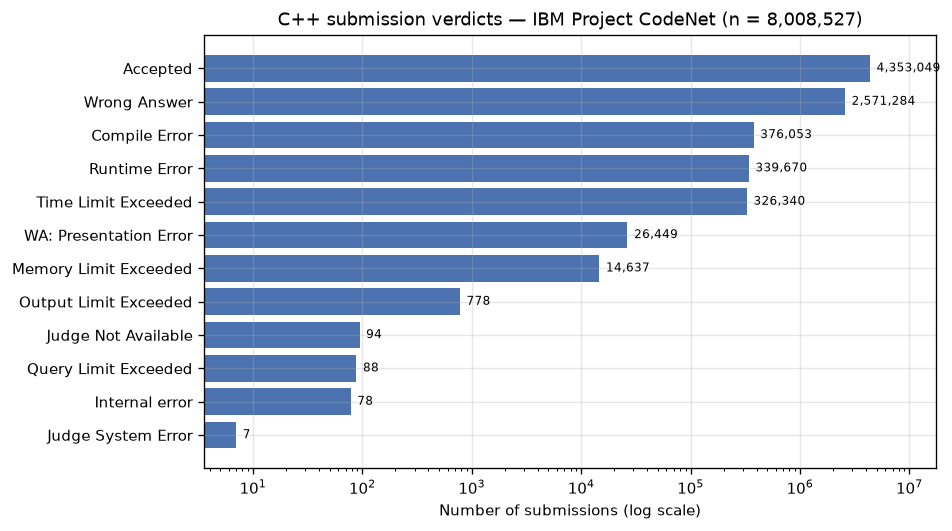

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(summary.index[::-1].astype(str), summary["count"][::-1], color="#4C72B0")
ax.set_xscale("log")
ax.set_xlabel("Number of submissions (log scale)")
ax.set_title("C++ submission verdicts — IBM Project CodeNet (n = 8,008,527)")

for i, v in enumerate(summary["count"][::-1]):
    ax.text(v * 1.15, i, f"{v:,}", va="center", fontsize=7)

ax.set_xlim(right=summary["count"].max() * 4)
fig.tight_layout()
fig.savefig(FIG / "verdict_distribution_cpp.png", bbox_inches="tight")
plt.show()

In [7]:
TIER = {
    "Accepted":      ("Tier 1", "ERROR-FREE"),
    "Wrong Answer":  ("Tier 1", "LOGICAL"),
    "Compile Error": ("Tier 2", "SYNTAX / SEMANTIC / LINKER"),
    "Runtime Error": ("Tier 3", "SIGSEGV / SIGFPE / SIGABRT / NZEC"),
}

rows = [
    {"tier": t, "verdict": s, "target_classes": c, "n": int((df["status"] == s).sum())}
    for s, (t, c) in TIER.items()
]
pool = pd.DataFrame(rows)
pool["pct_of_cpp"] = (pool["n"] / len(df) * 100).round(2)

kept = pool["n"].sum()
print(pool.to_string(index=False))
print(f"\nCandidate pool: {kept:,}  ({kept/len(df)*100:.2f}%)")
print(f"Discarded:      {len(df)-kept:,}  ({(len(df)-kept)/len(df)*100:.2f}%)")

print("\nDiscarded verdicts:")
print(df.loc[~df["status"].isin(TIER), "status"].value_counts().to_string())

  tier       verdict                    target_classes       n  pct_of_cpp
Tier 1      Accepted                        ERROR-FREE 4353049       54.36
Tier 1  Wrong Answer                           LOGICAL 2571284       32.11
Tier 2 Compile Error        SYNTAX / SEMANTIC / LINKER  376053        4.70
Tier 3 Runtime Error SIGSEGV / SIGFPE / SIGABRT / NZEC  339670        4.24

Candidate pool: 7,640,056  (95.40%)
Discarded:      368,471  (4.60%)

Discarded verdicts:
status
Time Limit Exceeded       326340
WA: Presentation Error     26449
Memory Limit Exceeded      14637
Output Limit Exceeded        778
Judge Not Available           94
Query Limit Exceeded          88
Internal error                78
Judge System Error             7
Accepted                       0
Compile Error                  0
Runtime Error                  0
Wrong Answer                   0


In [8]:
summary.to_csv(ROOT / "reports" / "verdict_distribution_cpp.csv")
pool.to_csv(ROOT / "reports" / "candidate_pool.csv", index=False)
print("Saved.")

Saved.


In [9]:
cand = df[df["status"].isin(TIER)].copy()
cand["status"] = cand["status"].cat.remove_unused_categories()
print(f"Candidate submissions: {len(cand):,}")
print(f"Distinct problems:     {cand['problem_id'].nunique():,}")

Candidate submissions: 7,640,056
Distinct problems:     4,032


In [14]:
chains = cand.groupby(["user_id", "problem_id"], observed=True).size()

multi = (chains > 1).sum()
in_chains = chains[chains > 1].sum()

print(f"(user, problem) pairs:        {len(chains):,}")
print(f"  with >1 submission:         {multi:,}  ({multi/len(chains)*100:.1f}%)")
print(f"Submissions in such chains:   {in_chains:,}  ({in_chains/len(cand)*100:.1f}%)")
print(f"Longest chain:                {chains.max()}")
print(f"\nChain length distribution:")
print(chains.value_counts().head(8).sort_index().to_string())

(user, problem) pairs:        3,992,111
  with >1 submission:         1,364,569  (34.2%)
Submissions in such chains:   5,012,514  (65.6%)
Longest chain:                764

Chain length distribution:
1    2627542
2     653304
3     286615
4     151865
5      88504
6      55077
7      35647
8      24129


In [15]:
print("Nulls by verdict:")
for st in TIER:
    s = cand[cand["status"] == st]
    print(f"  {st:<15} cpu_time: {s['cpu_time'].isna().sum():>8,}   "
          f"memory: {s['memory'].isna().sum():>8,}   (n={len(s):,})")

print("\nZero-valued (measured as 0, or not measured?):")
for st in TIER:
    s = cand[cand["status"] == st]
    print(f"  {st:<15} cpu_time==0: {(s['cpu_time'] == 0).sum():>8,}   "
          f"memory==0: {(s['memory'] == 0).sum():>8,}")

print("\nNegative values (IBM's documented warning):")
for col in ["cpu_time", "memory", "code_size"]:
    print(f"  {col:<12} {(cand[col] < 0).sum():,}")

Nulls by verdict:
  Accepted        cpu_time:        0   memory:        0   (n=4,353,049)
  Wrong Answer    cpu_time:        1   memory:        1   (n=2,571,284)
  Compile Error   cpu_time:  299,596   memory:  299,596   (n=376,053)
  Runtime Error   cpu_time:        0   memory:        0   (n=339,670)

Zero-valued (measured as 0, or not measured?):
  Accepted        cpu_time==0:  349,427   memory==0:   27,957
  Wrong Answer    cpu_time==0:  212,475   memory==0:   19,755
  Compile Error   cpu_time==0:   60,969   memory==0:   75,057
  Runtime Error   cpu_time==0:   31,882   memory==0:   10,930

Negative values (IBM's documented warning):
  cpu_time     171
  memory       0
  code_size    0


In [18]:
ol = cand["original_language"].value_counts()
ol = ol[ol > 0]
print(f"Distinct original_language values: {len(ol)}\n")
print(ol.head(10).to_string())  # Changed to head(10)

print(f"\nCompile Error rows only:")
ce = cand.loc[cand["status"] == "Compile Error", "original_language"].value_counts()
print(ce[ce > 0].head(10).to_string())

Distinct original_language values: 18

original_language
C++14 (GCC 5.4.1)                       4758434
C++ (GCC 9.2.1)                         1670127
C++                                      657902
C++14                                    161338
C++14 (Clang 3.8.0)                      110842
C++11                                    107776
C++ (GCC 5.4.1)                           85075
C++ (Clang 10.0.0)                        70109
C++ (GCC 9.2.1 with AC Library v1.1)      10793
C++ (Clang 3.8.0)                          4557

Compile Error rows only:
original_language
C++14 (GCC 5.4.1)                       206685
C++                                      65684
C++ (GCC 9.2.1)                          60243
C++14 (Clang 3.8.0)                      11303
C++ (Clang 10.0.0)                       11014
C++ (GCC 5.4.1)                           8983
C++11                                     6031
C++14                                     4738
C++ (Clang 3.8.0)                          

In [19]:
REP = ROOT / "reports"

per_problem.describe().to_csv(REP / "problems_per_submission_stats.csv")

pd.DataFrame({
    "metric": ["chain_pairs_pct", "submissions_in_chains_pct",
               "truncation_pct_overall", "candidate_pool", "problems"],
    "value":  [34.2, 65.6, 17.3, len(cand), cand["problem_id"].nunique()],
}).to_csv(REP / "eda_key_findings.csv", index=False)

print("Saved.")

Saved.


In [17]:
pl = pd.read_csv(RAW / "problem_list.csv")
judge = pl.set_index("id")["dataset"]
cand_judge = cand["problem_id"].map(judge)

print("Submissions by source judge:")
print(cand_judge.value_counts().to_string())

d = pd.to_datetime(cand["date"], unit="s", errors="coerce")
print(f"\nDate range: {d.min():%Y-%m-%d} to {d.max():%Y-%m-%d}")
print(f"Undateable rows: {d.isna().sum():,}")
print("\nSubmissions per year:")
print(d.dt.year.value_counts().sort_index().to_string())

Submissions by source judge:
problem_id
AtCoder    6713032
AIZU        927024

Date range: 2009-07-10 to 2020-10-01
Undateable rows: 0

Submissions per year:
date
2009       2017
2010      14206
2011      31242
2012      44499
2013      59760
2014      75477
2015     104724
2016     224462
2017     539342
2018     921403
2019    2188188
2020    3434736


In [10]:
per_problem = cand.groupby("problem_id", observed=True).size()

print(f"Problems with candidates: {len(per_problem):,}")
print(per_problem.describe(percentiles=[.25, .5, .75, .9, .99]).round(1).to_string())

share = per_problem.sort_values(ascending=False).cumsum() / per_problem.sum()
print("\nConcentration:")
for k in (10, 50, 100, 500, 1000):
    if k <= len(share):
        print(f"  Top {k:>4} problems hold {share.iloc[k-1]*100:5.1f}% of candidates")

Problems with candidates: 4,032
count     4032.0
mean      1894.9
std       3276.8
min          1.0
25%         87.0
50%        357.0
75%       2317.5
90%       6370.6
99%      13768.8
max      39830.0

Concentration:
  Top   10 problems hold   3.6% of candidates
  Top   50 problems hold  11.7% of candidates
  Top  100 problems hold  19.6% of candidates
  Top  500 problems hold  59.3% of candidates
  Top 1000 problems hold  84.3% of candidates


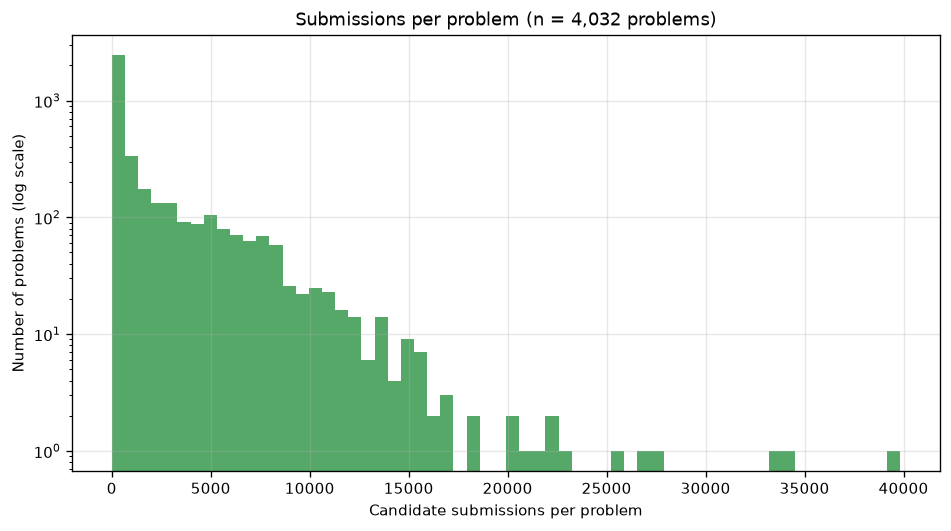

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(per_problem, bins=60, color="#55A868")
ax.set_yscale("log")
ax.set_xlabel("Candidate submissions per problem")
ax.set_ylabel("Number of problems (log scale)")
ax.set_title(f"Submissions per problem (n = {len(per_problem):,} problems)")
fig.tight_layout()
fig.savefig(FIG / "submissions_per_problem.png", bbox_inches="tight")
plt.show()

In [12]:
BYTES_PER_TOKEN = 3.5
LIMIT = int(512 * BYTES_PER_TOKEN)

size = cand["code_size"].dropna()
size = size[size > 0]

print(f"Valid code_size values: {len(size):,}  (of {len(cand):,})")
print(size.describe(percentiles=[.5, .75, .9, .95, .99]).round(0).to_string())
print(f"\nApprox. 512-token limit: {LIMIT} bytes")
print(f"Exceeding limit: {(size > LIMIT).mean()*100:.1f}%")

print("\nPer verdict:")
for st in TIER:
    s = cand.loc[cand["status"] == st, "code_size"].dropna()
    s = s[s > 0]
    print(f"  {st:<15} n={len(s):>9,}  median={s.median():>6.0f}B  "
          f"p95={s.quantile(.95):>7.0f}B  truncated={(s > LIMIT).mean()*100:5.1f}%")

Valid code_size values: 7,640,056  (of 7,640,056)
count    7640056.0
mean        1305.0
std         4169.0
min            1.0
50%          735.0
75%         1397.0
90%         2488.0
95%         3634.0
99%         8527.0
max       982666.0

Approx. 512-token limit: 1792 bytes
Exceeding limit: 17.3%

Per verdict:
  Accepted        n=4,353,049  median=   675B  p95=   3560B  truncated= 15.8%
  Wrong Answer    n=2,571,284  median=   845B  p95=   3732B  truncated= 19.7%
  Compile Error   n=  376,053  median=   435B  p95=   2829B  truncated= 10.5%
  Runtime Error   n=  339,670  median=  1059B  p95=   4328B  truncated= 25.9%


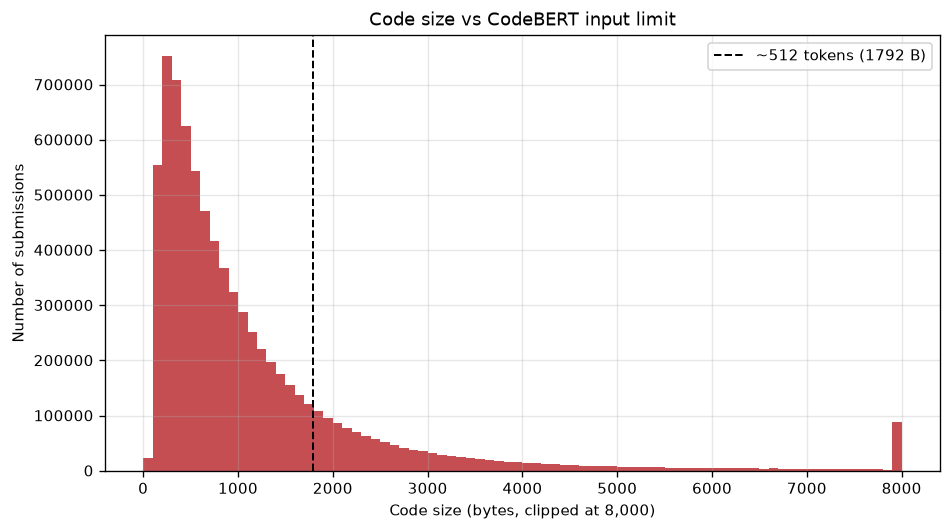

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(size.clip(upper=8000), bins=80, color="#C44E52")
ax.axvline(LIMIT, color="black", linestyle="--", linewidth=1.2,
           label=f"~512 tokens ({LIMIT} B)")
ax.set_xlabel("Code size (bytes, clipped at 8,000)")
ax.set_ylabel("Number of submissions")
ax.set_title("Code size vs CodeBERT input limit")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "code_size_distribution.png", bbox_inches="tight")
plt.show()

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
RAW  = ROOT / "data" / "raw"
FIG  = ROOT / "reports" / "figures"

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (8, 4.5),
    "font.size": 9,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

print(f"Raw data:  {RAW}   (exists: {RAW.exists()})")
print(f"Figures:   {FIG}   (exists: {FIG.exists()})")

Raw data:  d:\Dev\Github\transformer-defect-prediction\data\raw   (exists: True)
Figures:   d:\Dev\Github\transformer-defect-prediction\reports\figures   (exists: True)
